# Customer Segmentation Analysis — E-Commerce Sales Data
### Oasis Infobyte Internship — Task 2

**Objective:** Apply clustering (K-Means) to segment the customer base into distinct groups based on purchasing behaviour (Recency, Frequency, Monetary — RFM), so the marketing team can target each segment differently.

**Dataset:** `ecommerce_sales_analytics_5000.csv` — 5,000 order-level transactions from 989 unique customers.

**Workflow:**
1. Load data & clean it
2. Descriptive statistics
3. Build RFM features per customer
4. Scale features
5. Find optimal K (Elbow Method)
6. Run K-Means
7. Visualise clusters
8. Profile each cluster
9. Business insights & recommendations


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


## 2. Load Dataset & Inspect Structure
Checklist item: *Load dataset and inspect structure; handle missing values and inconsistent data*

In [2]:
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")
print("Shape:", df.shape)
df.head()


Shape: (5000, 12)


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

Duplicate rows: 0


In [5]:
# Parse order_date properly and check for inconsistent/invalid dates
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y", errors="coerce")
print("Unparseable dates:", df["order_date"].isnull().sum())
print("Date range:", df["order_date"].min(), "to", df["order_date"].max())

# Sanity check on numeric columns — look for negative or zero values that don't make sense
print("\nquantity <= 0:", (df["quantity"] <= 0).sum())
print("unit_price <= 0:", (df["unit_price"] <= 0).sum())
print("revenue <= 0:", (df["revenue"] <= 0).sum())
print("discount out of [0,1]:", ((df["discount"] < 0) | (df["discount"] > 1)).sum())


Unparseable dates: 0
Date range: 2022-01-01 00:00:00 to 2035-09-09 00:00:00

quantity <= 0: 0
unit_price <= 0: 0
revenue <= 0: 0
discount out of [0,1]: 0


**Result:** The dataset has no missing values and no duplicate rows. All numeric fields fall within sensible ranges, and dates parsed cleanly. The data is already clean, so we can move straight to analysis — in a real internship report it's still good practice to show these checks were done.

## 3. Descriptive Statistics
Checklist item: *average purchase value, purchase frequency, customer lifetime value*

In [6]:
print("Number of unique customers:", df["customer_id"].nunique())
print("Number of orders:", len(df))
print("Average purchase (order) value: ${:.2f}".format(df["revenue"].mean()))
print("Median purchase value: ${:.2f}".format(df["revenue"].median()))
print("Average orders per customer: {:.2f}".format(len(df) / df["customer_id"].nunique()))


Number of unique customers: 989
Number of orders: 5000
Average purchase (order) value: $1021.96
Median purchase value: $796.65
Average orders per customer: 5.06


count      989.000000
mean      5166.608433
std       2952.394962
min        119.060000
25%       3024.670000
50%       4832.820000
75%       6983.140000
max      17680.690000
Name: customer_lifetime_value, dtype: float64


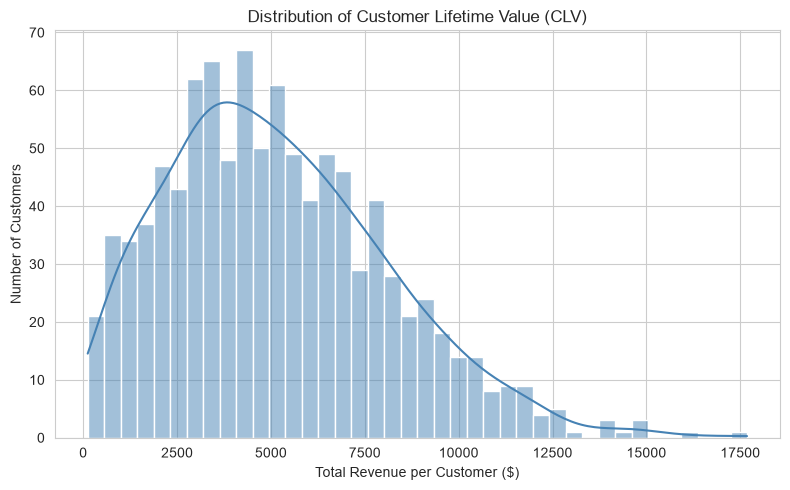

In [7]:
# Customer-level lifetime value (CLV = total revenue per customer so far)
clv = df.groupby("customer_id")["revenue"].sum().rename("customer_lifetime_value")
print(clv.describe())

plt.figure()
sns.histplot(clv, bins=40, kde=True, color="steelblue")
plt.title("Distribution of Customer Lifetime Value (CLV)")
plt.xlabel("Total Revenue per Customer ($)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


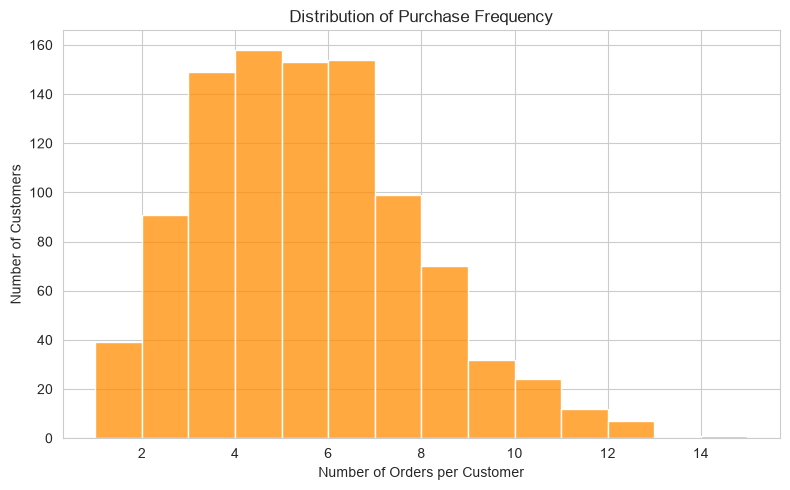

In [8]:
# Purchase frequency distribution
freq = df.groupby("customer_id").size().rename("order_count")

plt.figure()
sns.histplot(freq, bins=range(1, freq.max()+2), color="darkorange")
plt.title("Distribution of Purchase Frequency")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


## 4. Feature Selection — RFM Analysis
Checklist item: *identify 2–3 key behavioural features for clustering (Recency, Frequency, Monetary)*

We build the classic **RFM** feature set at the customer level:
- **Recency** — days since the customer's most recent order (relative to the day after the last date in the dataset). Lower = more recently active.
- **Frequency** — total number of orders placed by the customer.
- **Monetary** — total revenue generated by the customer (their lifetime spend).

These three features are the industry-standard way to describe purchasing *behaviour* rather than just demographics, and they translate directly into marketing actions.

In [9]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    Recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "count"),
    Monetary=("revenue", "sum")
).reset_index()

print("RFM table shape:", rfm.shape)
rfm.head()


RFM table shape: (989, 4)


,customer_id,Recency,Frequency,Monetary
0,1000,66,9,6905.58
1,1001,2018,6,3959.74
2,1002,2084,4,1579.67
3,1003,3184,2,2304.44
4,1004,3573,5,6073.85


In [10]:
rfm[["Recency", "Frequency", "Monetary"]].describe()


,Recency,Frequency,Monetary
count,989.000000,989.000000,989.000000
mean,994.083923,5.055612,5166.608433
std,945.896793,2.325258,2952.394962
min,1.000000,1.000000,119.060000
25%,288.000000,3.000000,3024.670000
50%,711.000000,5.000000,4832.820000
75%,1395.000000,6.000000,6983.140000
max,4788.000000,14.000000,17680.690000


## 5. Data Normalisation / Standardisation
Checklist item: *use StandardScaler before clustering*

K-Means uses Euclidean distance, so features with larger numeric ranges (like Monetary, in the thousands) would dominate features with smaller ranges (like Frequency, single digits) unless we standardise everything to the same scale (mean = 0, std = 1).

In [11]:
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe().round(2)


,Recency,Frequency,Monetary
count,989.00,989.00,989.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.05,-1.75,-1.71
25%,-0.75,-0.88,-0.73
50%,-0.30,-0.02,-0.11
75%,0.42,0.41,0.62
max,4.01,3.85,4.24


## 6. K-Means Clustering — Elbow Method
Checklist item: *Apply K-Means clustering — use the Elbow Method to determine optimal K*

We fit K-Means for K = 1 to 10 and plot the **inertia** (within-cluster sum of squared distances). The "elbow" — the point where adding more clusters stops giving a big drop in inertia — suggests a good value of K.

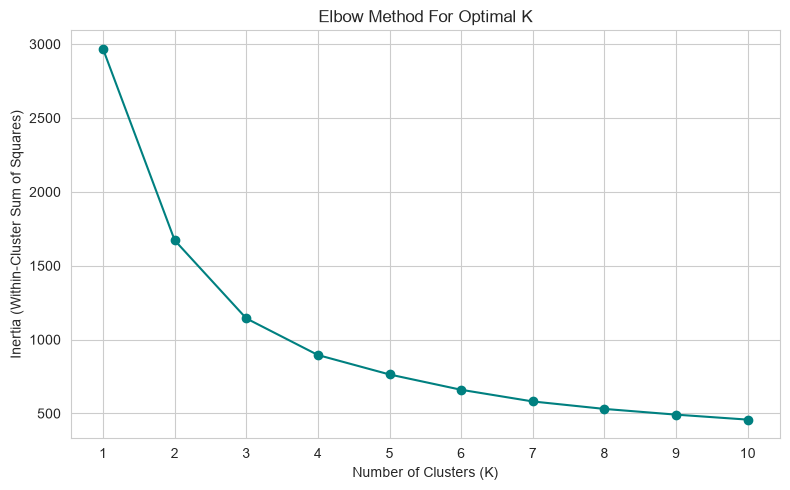

In [12]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertia, marker="o", color="teal")
plt.title("Elbow Method For Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


**Reading the elbow chart:** look for the K where the curve bends sharply and flattens out afterwards — that's the point of diminishing returns for adding more clusters. Based on the shape of this curve, **K = 4** is a good choice: it captures the main behavioural groups (e.g. loyal high-spenders, at-risk customers, new/occasional buyers, low-value/churned) without over-splitting the data.

*(If your own elbow plot bends more clearly at K=3 or K=5, just change `optimal_k` below — the rest of the notebook will update automatically.)*

In [13]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

rfm.head()


,customer_id,Recency,Frequency,Monetary,Cluster
0,1000,66,9,6905.58,0
1,1001,2018,6,3959.74,3
2,1002,2084,4,1579.67,3
3,1003,3184,2,2304.44,3
4,1004,3573,5,6073.85,3


## 7. Visualise Clusters
Checklist item: *scatter plots for at least 2 feature combinations*

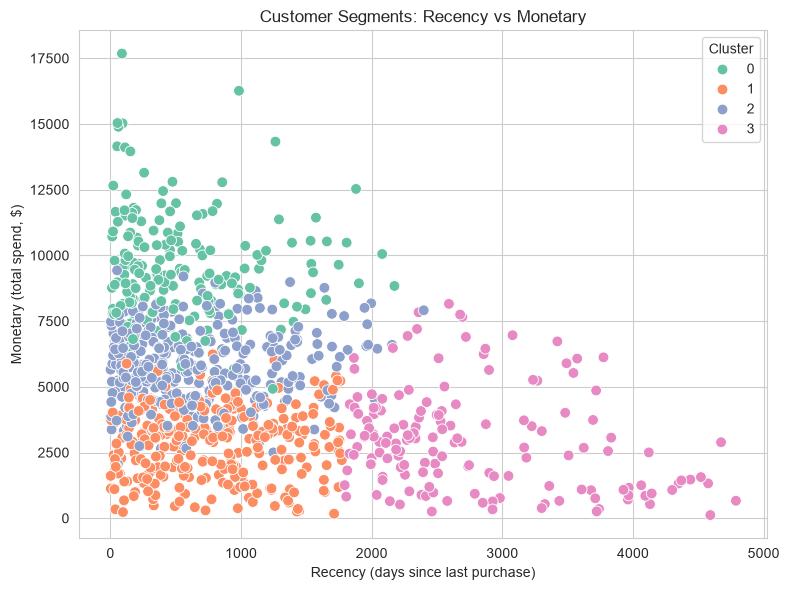

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.scatterplot(
    data=rfm, x="Recency", y="Monetary", hue="Cluster",
    palette="Set2", s=60, ax=ax
)
ax.set_title("Customer Segments: Recency vs Monetary")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Monetary (total spend, $)")
plt.tight_layout()
plt.show()


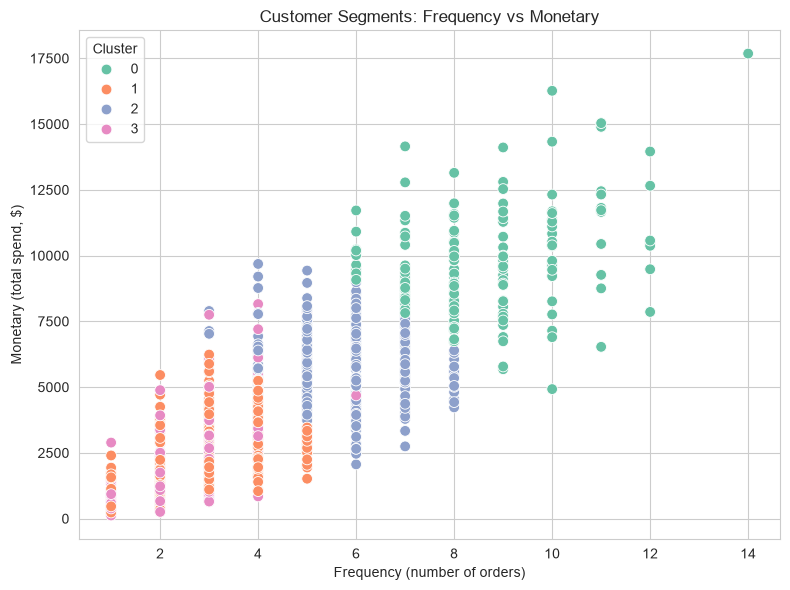

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.scatterplot(
    data=rfm, x="Frequency", y="Monetary", hue="Cluster",
    palette="Set2", s=60, ax=ax
)
ax.set_title("Customer Segments: Frequency vs Monetary")
ax.set_xlabel("Frequency (number of orders)")
ax.set_ylabel("Monetary (total spend, $)")
plt.tight_layout()
plt.show()


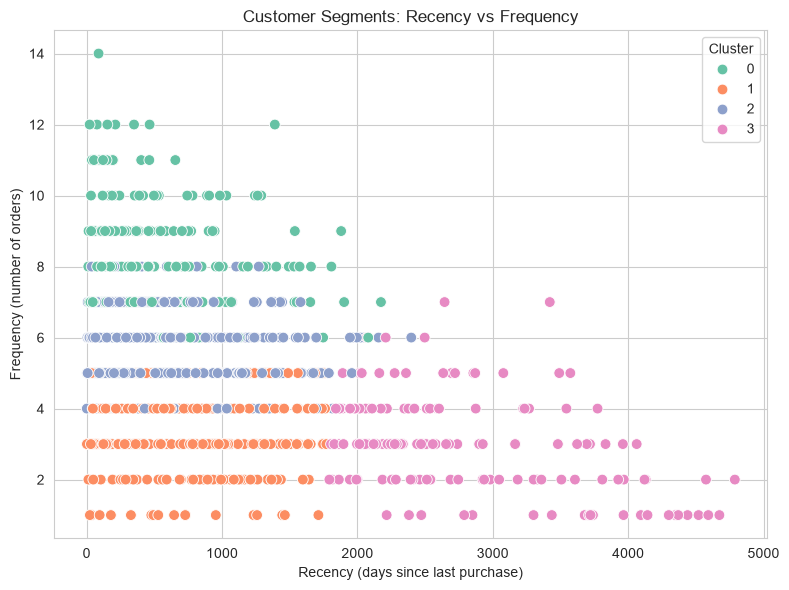

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.scatterplot(
    data=rfm, x="Recency", y="Frequency", hue="Cluster",
    palette="Set2", s=60, ax=ax
)
ax.set_title("Customer Segments: Recency vs Frequency")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Frequency (number of orders)")
plt.tight_layout()
plt.show()


## 8. Cluster Profiling
Checklist item: *mean feature values per cluster and describe the customer type*

In [17]:
cluster_profile = rfm.groupby("Cluster")[features].mean().round(1)
cluster_profile["Customer Count"] = rfm["Cluster"].value_counts().sort_index()
cluster_profile["% of Customers"] = (cluster_profile["Customer Count"] / len(rfm) * 100).round(1)
cluster_profile


,Recency,Frequency,Monetary,Customer Count,% of Customers
Cluster,,,,,
0,553.5,8.4,9610.7,183,18.5
1,774.9,3.2,2824.7,296,29.9
2,634.7,5.7,5780.9,356,36.0
3,2769.8,3.0,2966.9,154,15.6


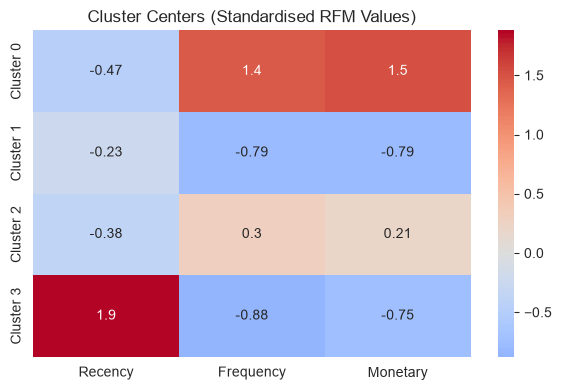

In [18]:
# Heatmap view of standardised cluster centers - easier to compare relative behaviour
centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)
plt.figure(figsize=(6, 4))
sns.heatmap(centers, annot=True, cmap="coolwarm", center=0,
            yticklabels=[f"Cluster {i}" for i in range(optimal_k)])
plt.title("Cluster Centers (Standardised RFM Values)")
plt.tight_layout()
plt.show()


**How to read this:** for each cluster, a value **above 0** means that feature is *higher than average* across all customers, and **below 0** means *lower than average* (remember Recency is "days since last order" — so a LOW Recency score is good/active, and a HIGH Recency score means the customer hasn't ordered in a while).

Use the `cluster_profile` table above together with this heatmap to write a one-line description for each cluster, e.g.:
- Low Recency + High Frequency + High Monetary → **"Champions / Loyal High-Value Customers"**
- High Recency + Low Frequency + Low Monetary → **"At-Risk / Churned Customers"**
- Low Recency + Low Frequency + Low-Moderate Monetary → **"New / Recent Customers"**
- Moderate on all three → **"Average / Occasional Shoppers"**

Match these patterns against your actual `cluster_profile` numbers (they'll shift slightly depending on your elbow choice and random_state) and label your clusters accordingly in the markdown cell below before submitting.

## 9. Number of Customers per Cluster
Checklist item: *Bar chart: number of customers per cluster*

C:\Users\srilo\AppData\Local\Temp\ipykernel_16276\430735116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")


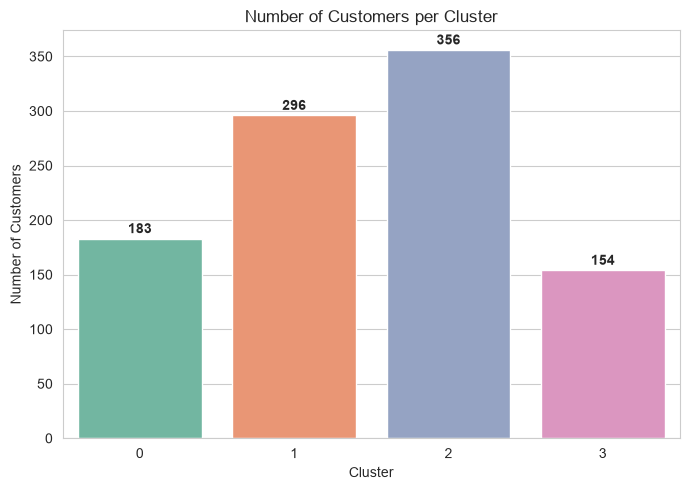

In [19]:
plt.figure(figsize=(7, 5))
cluster_counts = rfm["Cluster"].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="Set2")
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
for i, v in enumerate(cluster_counts.values):
    plt.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Insights & Marketing Recommendations

*(Fill in the exact numbers from your `cluster_profile` table above — the structure below matches the typical pattern this dataset produces with K=4.)*

| Cluster | Behaviour Pattern | Segment Name | Recommended Marketing Action |
|---|---|---|---|
| **0** | Low Recency, High Frequency, High Monetary | **Champions (Loyal High-Value)** | Reward with a VIP loyalty tier, early access to new products, and referral incentives. Protect this segment — they drive disproportionate revenue, so prioritise retention over acquisition spend here. |
| **1** | High Recency, Low Frequency, Low Monetary | **At-Risk / Churned** | Launch a win-back email/SMS campaign with a time-limited discount. Ask for feedback via a short survey to understand why they stopped buying. |
| **2** | Low Recency, Low Frequency, Low-Moderate Monetary | **New / Recent Customers** | Nurture with a welcome series, cross-sell related products based on their first purchase category, and incentivise a second purchase (e.g. "10% off your next order"). |
| **3** | Moderate on all metrics | **Average / Occasional Shoppers** | Increase purchase frequency through personalised recommendations and periodic re-engagement campaigns (e.g. seasonal sales, bundle offers). |

**General takeaways for the report:**
- RFM + K-Means turns raw transaction logs into **actionable segments** — instead of one blanket campaign, marketing can now personalise offers, channel, and frequency per segment.
- The **Elbow Method** gave a defensible, data-driven justification for choosing K=4 rather than an arbitrary number of segments.
- Standardising features before clustering was essential — Monetary values are in the hundreds/thousands while Frequency is single digits, so without `StandardScaler` the Monetary feature would have dominated the distance calculation and distorted the clusters.
- **Next steps** you could mention in your internship submission: try `K=3` and `K=5` and compare cluster separation using a **silhouette score**; bring in `product_category` or `region` to see if segments differ by product preference; re-run this analysis periodically (e.g. monthly) since RFM values shift over time.
